### 1. Data Cleaning

In [1]:
# Import liabraries
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Set paths
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

METADATA_PATH = (
    RAW_DATA_DIR /
    "HAM10000_metadata.csv"
)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA_DIR)
print("Processed data:", PROCESSED_DATA_DIR)

Project root: c:\Deep Learning\skin-lesion-classification
Raw data: c:\Deep Learning\skin-lesion-classification\data\raw
Processed data: c:\Deep Learning\skin-lesion-classification\data\processed


In [3]:
# Import cleaning functions
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.cleaning import (
    collect_image_paths,
    clean_ham10000
)

In [4]:
# Load raw metadata
raw_df = pd.read_csv(METADATA_PATH)

print("Raw metadata shape:", raw_df.shape)

raw_df.head()

Raw metadata shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# Exact duplicates
exact_duplicates = raw_df.duplicated().sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

Exact duplicate rows: 0


In [6]:
# Duplicate image IDs
duplicate_image_ids = (
    raw_df["image_id"]
    .duplicated()
    .sum()
)

print(
    "Duplicate image IDs:",
    duplicate_image_ids
)

Duplicate image IDs: 0


In [7]:
# Inspect diagnosis labels
print(
    raw_df["dx"]
    .value_counts(dropna=False)
)

print(
    "\nUnique labels:",
    raw_df["dx"].unique()
)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Unique labels: <StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str


In [8]:
# Check required metadata values
required_fields = [
    "lesion_id",
    "image_id",
    "dx"
]

for column in required_fields:
    missing = raw_df[column].isna().sum()

    print(
        f"{column:<15}: "
        f"{missing} missing values"
    )

lesion_id      : 0 missing values
image_id       : 0 missing values
dx             : 0 missing values


In [9]:
# Inspect optional metadata missing values
missing_summary = pd.DataFrame({
    "missing_count":
        raw_df.isna().sum(),

    "missing_percentage":
        raw_df.isna().mean() * 100
})

missing_summary.sort_values(
    "missing_count",
    ascending=False
)

,missing_count,missing_percentage
age,57,0.569146
image_id,0,0.000000
lesion_id,0,0.000000
dx,0,0.000000
dx_type,0,0.000000
sex,0,0.000000
localization,0,0.000000


In [10]:
# Age validity
age_numeric = pd.to_numeric(
    raw_df["age"],
    errors="coerce"
)

print(age_numeric.describe())

invalid_age = raw_df[
    (age_numeric < 0) |
    (age_numeric > 120)
]

print(
    "\nInvalid ages:",
    len(invalid_age)
)

count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64

Invalid ages: 0


In [11]:
# Check actual image files
image_map = collect_image_paths(
    RAW_DATA_DIR
)

print(
    "Number of image files:",
    len(image_map)
)

print(
    "Metadata records:",
    len(raw_df)
)

Number of image files: 10015
Metadata records: 10015


In [12]:
# Missing images
metadata_ids = set(
    raw_df["image_id"]
    .astype(str)
    .str.strip()
)

file_ids = set(image_map.keys())

missing_image_ids = (
    metadata_ids - file_ids
)

extra_image_ids = (
    file_ids - metadata_ids
)

print(
    "Metadata rows without image file:",
    len(missing_image_ids)
)

print(
    "Image files without metadata:",
    len(extra_image_ids)
)

Metadata rows without image file: 0
Image files without metadata: 0


In [13]:
image_map = collect_image_paths(RAW_DATA_DIR)

print("Metadata image ID:")
print(raw_df["image_id"].iloc[0])

print("\nExample image map key:")
print(next(iter(image_map.keys())))

Metadata image ID:
ISIC_0027419

Example image map key:
ISIC_0024306


In [14]:
# Run data cleaning
clean_df, cleaning_report = (
    clean_ham10000(
        df=raw_df,
        raw_data_dir=RAW_DATA_DIR,
        verify_images=True
    )
)

In [15]:
# Report cleaning results
print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

for key, value in cleaning_report.items():

    if key != "corrupted_images":
        print(
            f"{key:<35}: {value}"
        )

DATA CLEANING REPORT
initial_rows                       : 10015
exact_duplicates_removed           : 0
duplicate_image_ids_removed        : 0
invalid_class_rows_removed         : 0
image_files_found                  : 10015
missing_image_rows_removed         : 0
corrupted_images_removed           : 0
final_rows                         : 10015
rows_removed_total                 : 0


In [16]:
# Inspect corrupted images
corrupted_images = (
    cleaning_report[
        "corrupted_images"
    ]
)

if corrupted_images:

    corrupted_df = pd.DataFrame(
        corrupted_images
    )

    display(corrupted_df)

else:
    print(
        "No corrupted images detected."
    )

No corrupted images detected.


In [17]:
# Validate cleaned dataset 
print(
    "Cleaned shape:",
    clean_df.shape
)

print(
    "\nMissing required values:"
)

print(
    clean_df[
        [
            "lesion_id",
            "image_id",
            "dx",
            "image_path"
        ]
    ].isna().sum()
)



Cleaned shape: (10015, 8)

Missing required values:
lesion_id     0
image_id      0
dx            0
image_path    0
dtype: int64


In [18]:
# Check final labels
clean_df["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: Int64

In [19]:
# Compare class distribution before and after cleaning
before_counts = (
    raw_df["dx"]
    .value_counts()
    .sort_index()
)

after_counts = (
    clean_df["dx"]
    .value_counts()
    .sort_index()
)

comparison_df = pd.DataFrame({
    "before_cleaning":
        before_counts,

    "after_cleaning":
        after_counts
}).fillna(0)

comparison_df["removed"] = (
    comparison_df["before_cleaning"] -
    comparison_df["after_cleaning"]
)

comparison_df

,before_cleaning,after_cleaning,removed
dx,,,
akiec,327,327,0
bcc,514,514,0
bkl,1099,1099,0
df,115,115,0
mel,1113,1113,0
nv,6705,6705,0
vasc,142,142,0


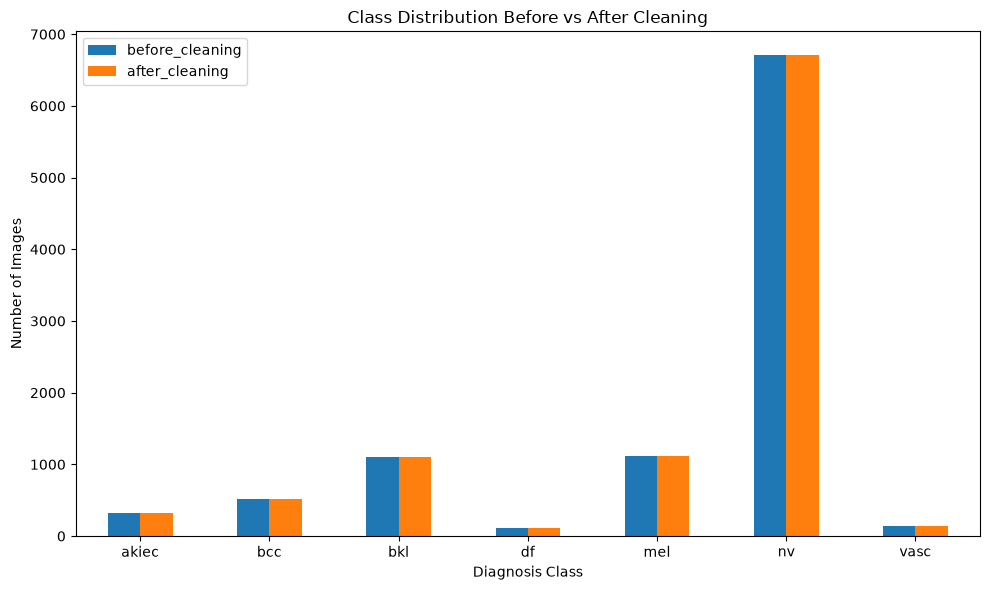

In [20]:
# Visualize class distribution
comparison_df[
    [
        "before_cleaning",
        "after_cleaning"
    ]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Class Distribution Before vs After Cleaning"
)

plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [21]:
# Check lesion information is preserved after cleaning
print(
    "Unique lesions before cleaning:",
    raw_df["lesion_id"].nunique()
)

print(
    "Unique lesions after cleaning:",
    clean_df["lesion_id"].nunique()
)

print(
    "\nLesions with multiple images:",
    (
        clean_df["lesion_id"]
        .value_counts() > 1
    ).sum()
)

Unique lesions before cleaning: 7470
Unique lesions after cleaning: 7470

Lesions with multiple images: 1956


In [22]:
# Save cleaned metadata 
clean_df_to_save = clean_df.copy()

clean_df_to_save["image_path"] = (
    clean_df_to_save["image_path"]
    .apply(
        lambda path:
        Path(path)
        .relative_to(PROJECT_ROOT)
        .as_posix()
    )
)

CLEAN_METADATA_PATH = (
    PROCESSED_DATA_DIR /
    "HAM10000_metadata_clean.csv"
)

clean_df_to_save.to_csv(
    CLEAN_METADATA_PATH,
    index=False
)

print(
    "Saved:",
    CLEAN_METADATA_PATH
)

clean_df_to_save.head()

Saved: c:\Deep Learning\skin-lesion-classification\data\processed\HAM10000_metadata_clean.csv


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0027419.jpg
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025030.jpg
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0026769.jpg
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,data/raw/HAM10000_images_part_1/ISIC_0025661.jpg
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,data/raw/HAM10000_images_part_2/ISIC_0031633.jpg


In [23]:
# Summary of cleaning 
initial_rows = len(raw_df)
final_rows = len(clean_df)

removed_rows = (
    initial_rows - final_rows
)

print("=" * 70)
print("HAM10000 DATA CLEANING SUMMARY")
print("=" * 70)

print(f"""
Initial metadata records : {initial_rows:,}
Final valid records      : {final_rows:,}
Removed records          : {removed_rows:,}

Exact duplicates removed :
    {cleaning_report['exact_duplicates_removed']}

Duplicate image IDs removed :
    {cleaning_report['duplicate_image_ids_removed']}

Invalid diagnosis labels removed :
    {cleaning_report['invalid_class_rows_removed']}

Missing image files removed :
    {cleaning_report['missing_image_rows_removed']}

Corrupted images removed :
    {cleaning_report['corrupted_images_removed']}

Cleaning decisions:
- Required identifiers were validated.
- Diagnosis labels were restricted to the 7 HAM10000 classes.
- Image files were matched with metadata using image_id.
- Missing/corrupted images were excluded if present.
- Missing optional demographic metadata was retained.
- Repeated lesion_id values were preserved because one lesion may
  legitimately have multiple images.
- No resizing, normalization, augmentation, or dataset splitting
  was performed in this stage.
""")

HAM10000 DATA CLEANING SUMMARY

Initial metadata records : 10,015
Final valid records      : 10,015
Removed records          : 0

Exact duplicates removed :
    0

Duplicate image IDs removed :
    0

Invalid diagnosis labels removed :
    0

Missing image files removed :
    0

Corrupted images removed :
    0

Cleaning decisions:
- Required identifiers were validated.
- Diagnosis labels were restricted to the 7 HAM10000 classes.
- Image files were matched with metadata using image_id.
- Missing/corrupted images were excluded if present.
- Missing optional demographic metadata was retained.
- Repeated lesion_id values were preserved because one lesion may
  legitimately have multiple images.
- No resizing, normalization, augmentation, or dataset splitting
  was performed in this stage.

